<div align="center">



# **Análisis y Procesamiento de Señales**

## **Trabajo Semanal 2: Modelizando un ADC**



</div>

<br>
<br>
<br>
<br>

**Alumno:** Germán Fiore  
**Especialidad:** Ingeniería Biomédica  
**Fecha:** 09/09/2026  

---

### **Introducción**
Para poder procesar cualquier señal analógica en una computadora o un microcontrolador, primero necesitamos pasarla al mundo digital. De este trabajo se encarga el Conversor Analógico-Digital (ADC), que básicamente hace dos cosas: toma muestras de la señal cada cierto tiempo (muestreo a una frecuencia $f_s$) y redondea esos valores de voltaje a un conjunto finito de niveles discretos (cuantización usando $B$ bits dentro de un rango de $\pm V_F$ Volts). Este proceso de redondeo define el paso de cuantización ($q$), que representa el escalón mínimo de tensión (o LSB) que el conversor es capaz de resolver. Este paso se calcula como: $$q = \frac{V_R}{2^B}$$ Donde $V_R$ es el rango de tensión de referencia del conversor (que para nuestra simulación vale $2.0\text{ V}$) y $B$ es la cantidad de bits de resolución 

<br>

Como en la práctica ninguna señal analógica es perfecta y siempre vienen con interferencias, en este trabajo vamos a simular una señal de entrada real sumándole a una senoidal pura un ruido blanco de tipo Gaussiano: $s_R[n] = s[n] + n[n]$. Lo interesante de la simulación es cómo calibramos ese ruido de entrada: para poder comparar el ruido "externo" (el analógico) con el ruido propio de redondeo que mete el ADC, definimos la potencia del ruido analógico ($P_n$) como un múltiplo de la potencia de cuantización teórica ($P_q = q^2/12$): $$P_n = k_n \cdot P_q$$ Donde $k_n$ es el factor de escala que nos va a permitir analizar qué ruido es el que termina arruinando la señal.

### **Objetivos**
El objetivo de esta tarea semanal es simular y modelar en Python el comportamiento de un ADC bipolar de $\pm 2\text{ V}$ con una frecuencia de muestreo de $1000\text{ Hz}$. Para ver cómo responde el sistema, vamos a ir cambiando y cruzando dos variables clave: la resolución del conversor ($B = \{4, 8, 16\}$ bits) y la cantidad de ruido aditivo ($k_n = \{0.1, 1, 10\}$).
Finalmente, para medir qué tan bien (o qué tan mal) quedó nuestra señal digitalizada, vamos a calcular la SNR teórica y compararla con la experimental de la simulación.

### **Codigo Completo**

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def simular(bits_adc, escala_ruido):
    frecuencia_muestreo = 1000.0  # Frecuencia fs (1000 Hz)
    cant_muestras = 1000          # Muestras N
    v_rango = 2.0                 # Rango V_R (+/- 2.0 V)

    tiempo = np.arange(cant_muestras) / frecuencia_muestreo

    # Paso de cuantización (q = V_R / 2^B)
    paso_cuantizacion = v_rango / (2**bits_adc)

    # GENERACIÓN DE SEÑALES
    frec_fundamental = frecuencia_muestreo / cant_muestras
    senoidal_pura = np.sqrt(2) * np.sin(2 * np.pi * frec_fundamental * tiempo)

    # Potencias teóricas de ruido
    potencia_cuantizacion = (paso_cuantizacion**2) / 12
    potencia_ruido_analogico = escala_ruido * potencia_cuantizacion

    # Ruido analógico n(t)
    ruido_analogico = np.random.normal(0, np.sqrt(potencia_ruido_analogico), cant_muestras)

    # Señal s_R(t) = s(t) + n(t)
    senal_contaminada = senoidal_pura + ruido_analogico

    # CUANTIZACIÓN (ADC) Y ERROR
    senal_cuantizada = paso_cuantizacion * np.round(senal_contaminada / paso_cuantizacion)
    senal_cuantizada = np.clip(senal_cuantizada, -v_rango, v_rango - paso_cuantizacion)
    error_cuantizacion = senal_cuantizada - senal_contaminada

    # ANÁLISIS ESPECTRAL (PSD) Y PISOS DE RUIDO
    fft_pura = np.fft.rfft(senoidal_pura) / cant_muestras
    fft_contaminada = np.fft.rfft(senal_contaminada) / cant_muestras
    fft_cuantizada = np.fft.rfft(senal_cuantizada) / cant_muestras

    psd_pura = np.abs(fft_pura)**2
    psd_contaminada = np.abs(fft_contaminada)**2
    psd_cuantizada = np.abs(fft_cuantizada)**2

    psd_pura[1:-1] *= 2
    psd_contaminada[1:-1] *= 2
    psd_cuantizada[1:-1] *= 2

    psd_pura_db = 10 * np.log10(psd_pura + 1e-12)
    psd_contaminada_db = 10 * np.log10(psd_contaminada + 1e-12)
    psd_cuantizada_db = 10 * np.log10(psd_cuantizada + 1e-12)

    frecuencias = np.fft.rfftfreq(cant_muestras, d=1/frecuencia_muestreo)

    piso_analogico_db = 10 * np.log10(potencia_ruido_analogico / (cant_muestras / 2))
    piso_digital_db = 10 * np.log10(potencia_cuantizacion / (cant_muestras / 2))


   
    # CÁLCULO DE SNR EXPERIMENTAL Y TEÓRICO
    
    # Potencia de la señal deseada
    potencia_senal = np.mean(senoidal_pura**2) 

    # Potencia del error total observado en la simulación
    error_total = senal_cuantizada - senoidal_pura
    potencia_error_experimental = np.mean(error_total**2)

    # Potencia teórica total del ruido (Ruido analógico + Ruido de cuantización)
    # P_n_teorico = P_analogico + P_cuantizacion = kn * Pq + Pq = (kn + 1) * Pq
    potencia_error_teorica = (escala_ruido + 1.0) * potencia_cuantizacion

    # Cálculo de SNRs en dB
    snr_experimental = 10 * np.log10(potencia_senal / potencia_error_experimental)
    snr_teorico = 10 * np.log10(potencia_senal / potencia_error_teorica)
    
    # VISUALIZACIÓN
    # --- Gráfico 1: Dominio del Tiempo ---
    plt.figure(figsize=(10, 4))
    plt.plot(tiempo, senal_cuantizada, label=r"$s_Q = Q_{B, V_R}\{s_R\}$ (ADC out)", color="tab:blue", lw=1.5)
    plt.plot(tiempo, senal_contaminada, color="green", linestyle=":", marker="o", markersize=2, label=r"$s_R = s + n$ (ADC in)", alpha=0.7)
    plt.plot(tiempo, senoidal_pura, color="orange", linestyle="--", label=r"$s$ (analog)", lw=1.2)
    plt.title(rf"Señal muestreada por un ADC de {bits_adc} bits - $\pm V_R = {v_rango}\text{{ V}} - q = {paso_cuantizacion}\text{{ V}}$")
    plt.xlabel("tiempo [segundos]")
    plt.ylabel("Amplitud [V]")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # --- Gráfico 2: Densidad Espectral de Potencia (PSD) ---
    plt.figure(figsize=(10, 4))
    plt.plot(frecuencias, psd_cuantizada_db, color="tab:blue", lw=1.0, label=r"$s_Q = Q_{B, V_R}\{s_R\}$ (ADC out)")
    plt.plot(frecuencias, psd_pura_db, color="orange", linestyle="--", lw=1.0, label=r"$s$ (analog)")
    plt.plot(frecuencias, psd_contaminada_db, color="green", linestyle=":", alpha=0.6, label=r"$s_R = s + n$ (ADC in)")
    plt.axhline(piso_analogico_db, color="red", linestyle="--", label=rf"$\overline{{n}} = {piso_analogico_db:.1f}\text{{ dB}}$ (piso analog.)")
    plt.axhline(piso_digital_db, color="cyan", linestyle="--", label=rf"$\overline{{n}}_Q = {piso_digital_db:.1f}\text{{ dB}}$ (piso digital)")
    plt.title(rf"Señal muestreada por un ADC de {bits_adc} bits - $\pm V_R = {v_rango}\text{{ V}} - q = {paso_cuantizacion}\text{{ V}}$")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Densidad de Potencia [dB]")
    piso_minimo = min(piso_analogico_db, piso_digital_db)
    plt.ylim(piso_minimo - 10, 10)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # --- Gráfico 3: Histograma del Error ---
    plt.figure(figsize=(10, 4))
    plt.hist(error_cuantizacion, bins=10, color="tab:blue", edgecolor="white")
    plt.plot([-paso_cuantizacion/2, -paso_cuantizacion/2, paso_cuantizacion/2, paso_cuantizacion/2], [0, 100, 100, 0], 'r--', lw=1.5)
    plt.xlabel("Error de cuantización $e_q$ [V]") 
    plt.ylabel("Cantidad de muestras")
    plt.title(rf"Ruido de cuantización para {bits_adc} bits - $\pm V_R = {v_rango}\text{{ V}} - q = {paso_cuantizacion}\text{{ V}}$")
    plt.xlim(-paso_cuantizacion, paso_cuantizacion)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

    print(f"SNR Experimental: {snr_experimental:.2f} dB")
    print(f"SNR Teórica: {snr_teorico:.2f} dB")

<br>

$B = 4$ y $k_n = 1$

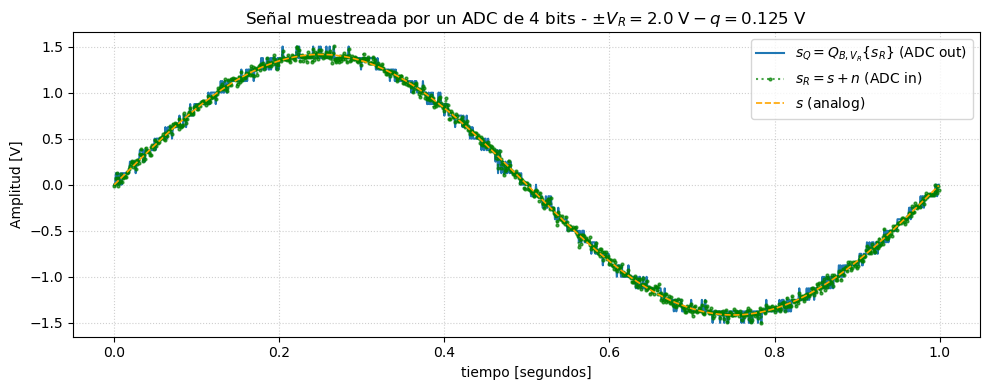

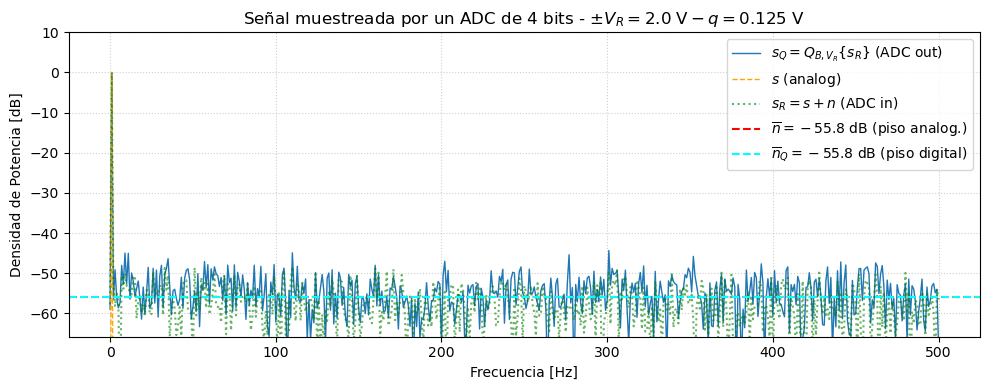

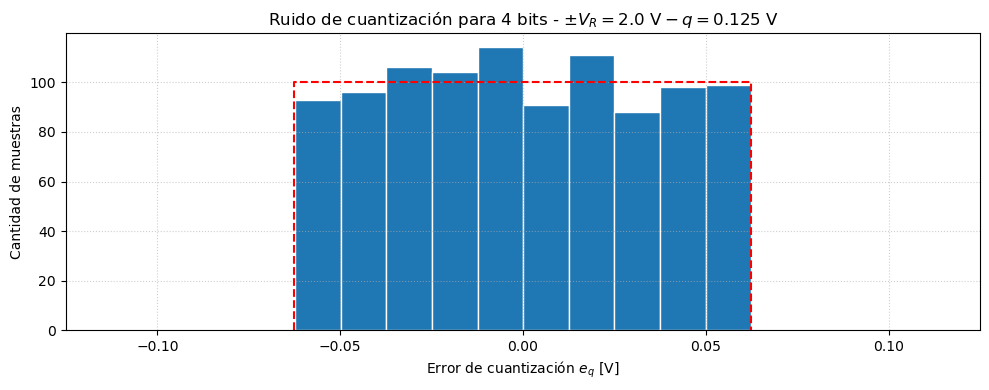

SNR Experimental: 26.06 dB
SNR Teórica: 25.84 dB


In [7]:
simular(bits_adc=4, escala_ruido=1.0)

<br>

$B = 4$ y $k_n = 0.1$

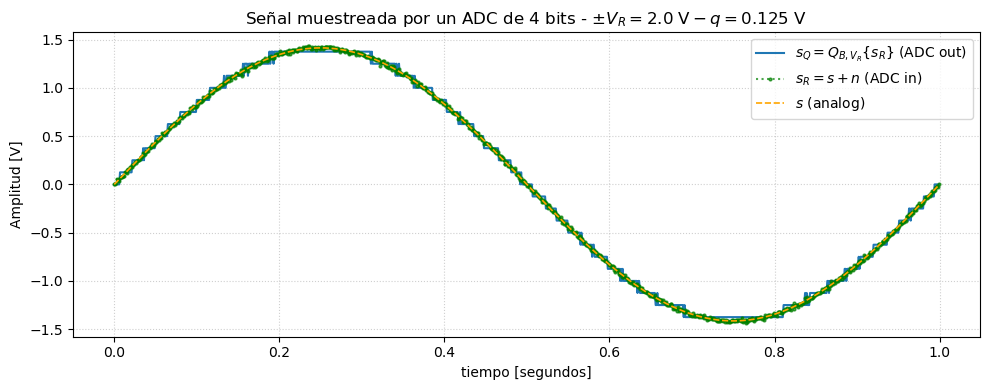

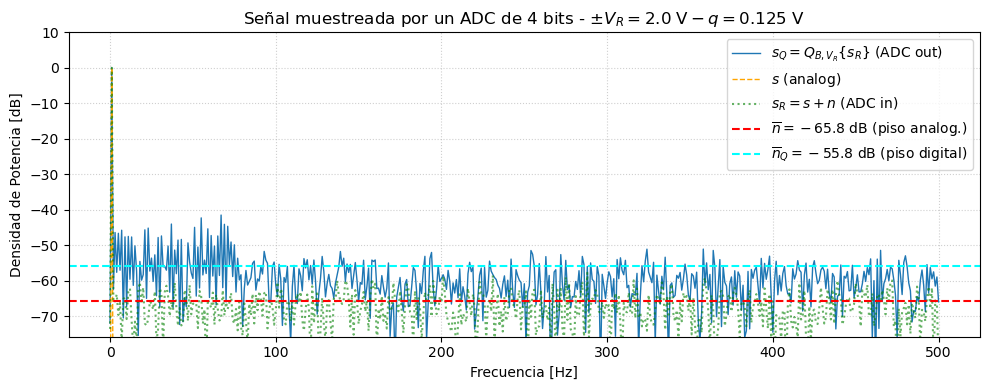

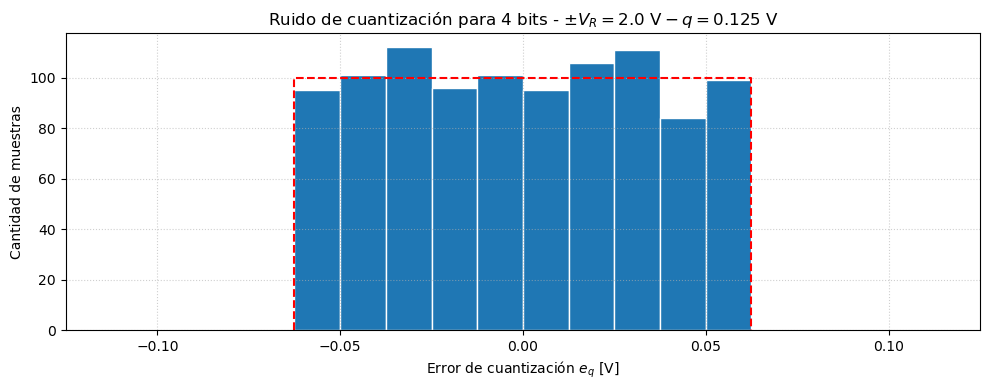

SNR Experimental: 28.78 dB
SNR Teórica: 28.44 dB


In [8]:
simular(bits_adc=4, escala_ruido=0.1)

<br>

$B = 4$ y $k_n = 10$

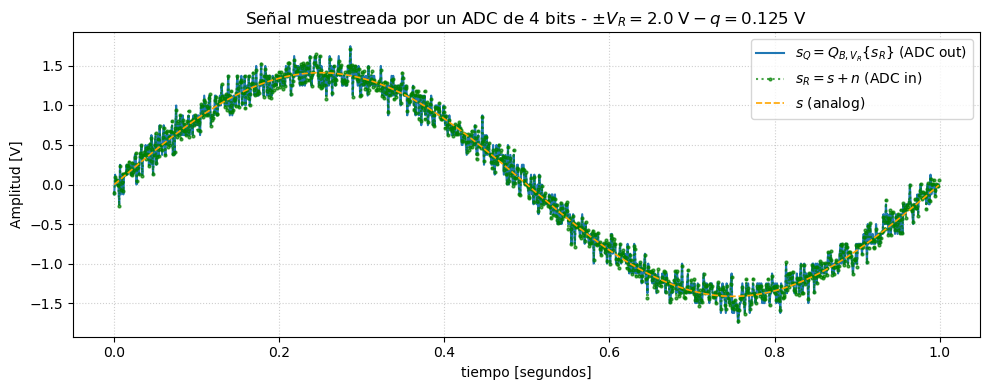

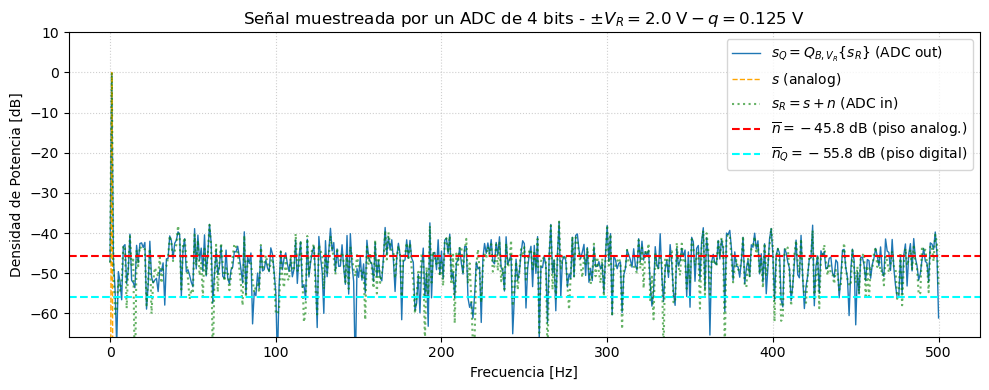

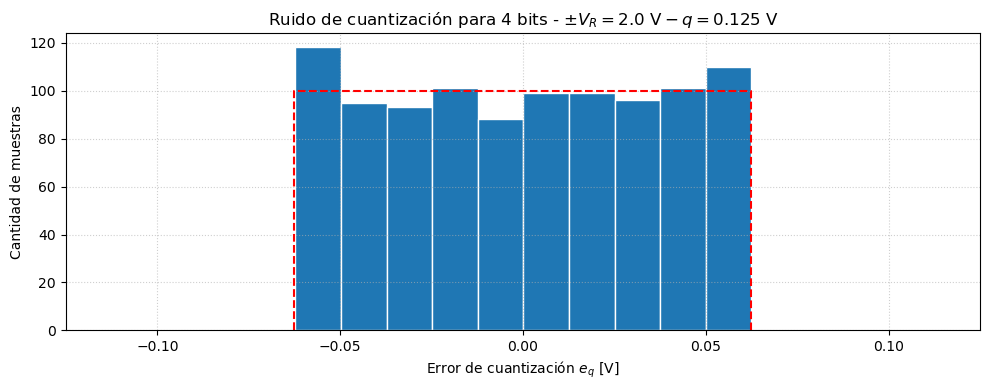

SNR Experimental: 18.42 dB
SNR Teórica: 18.44 dB


In [9]:
simular(bits_adc=4, escala_ruido=10)

<br>

$B = 8$ y $k_n = 0.1$

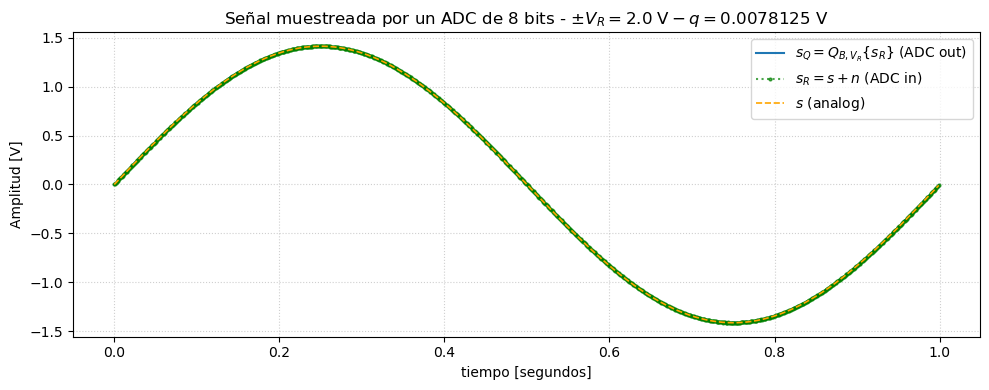

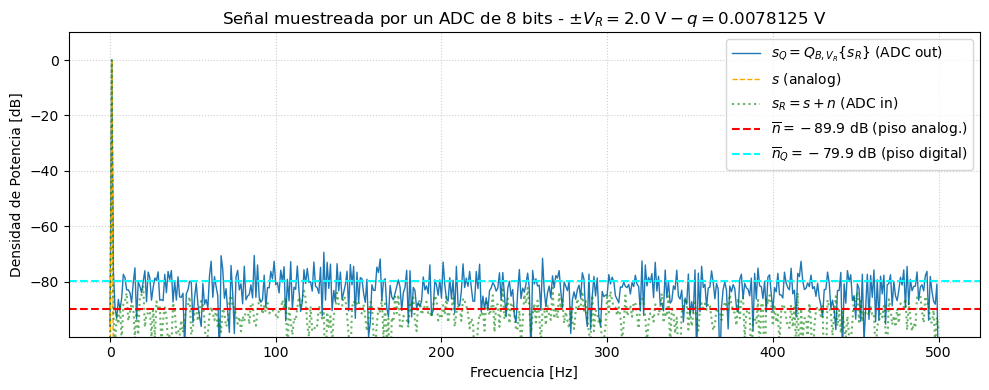

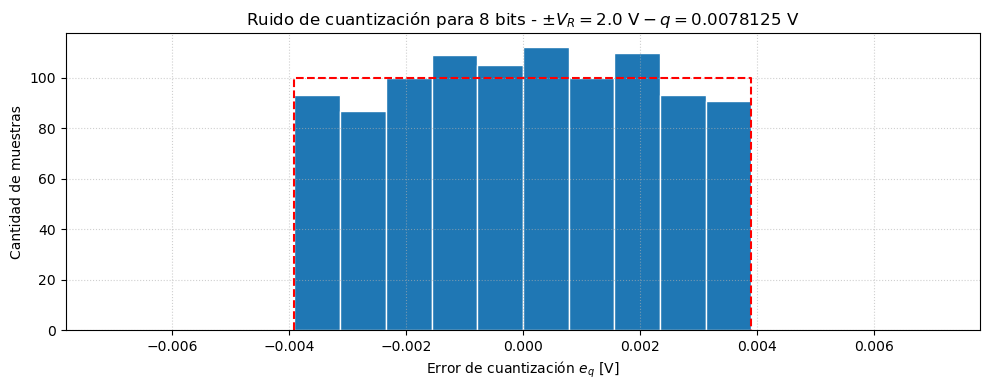

SNR Experimental: 53.01 dB
SNR Teórica: 52.52 dB


In [10]:
simular(bits_adc=8, escala_ruido=0.1)

<br>

$B = 8$ y $k_n = 1$

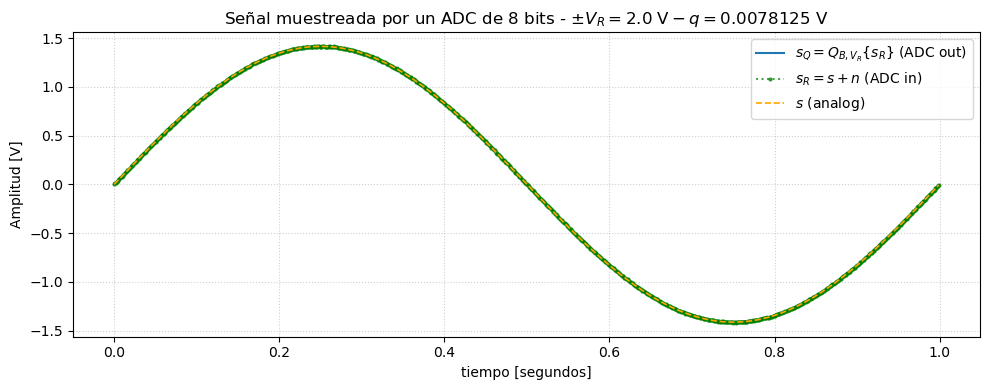

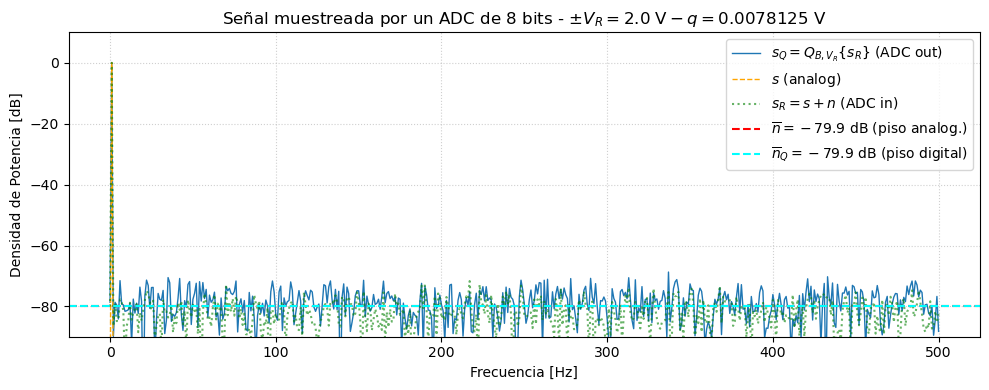

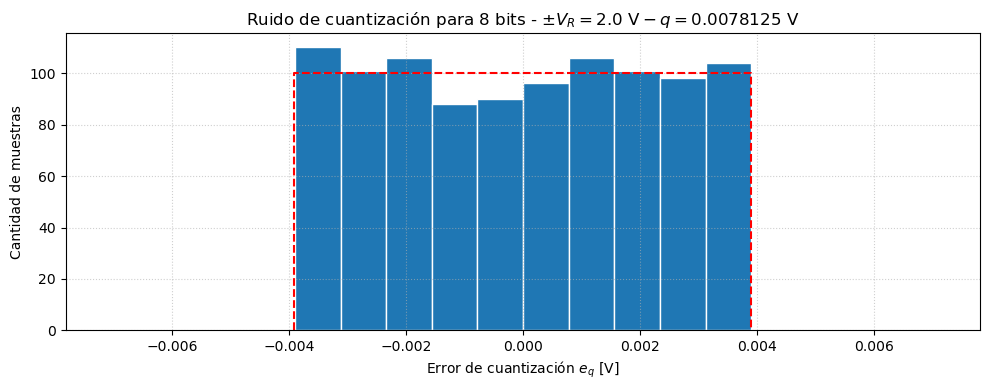

SNR Experimental: 49.98 dB
SNR Teórica: 49.93 dB


In [11]:
simular(bits_adc=8, escala_ruido=1)

<br>

$B = 8$ y $k_n = 10$

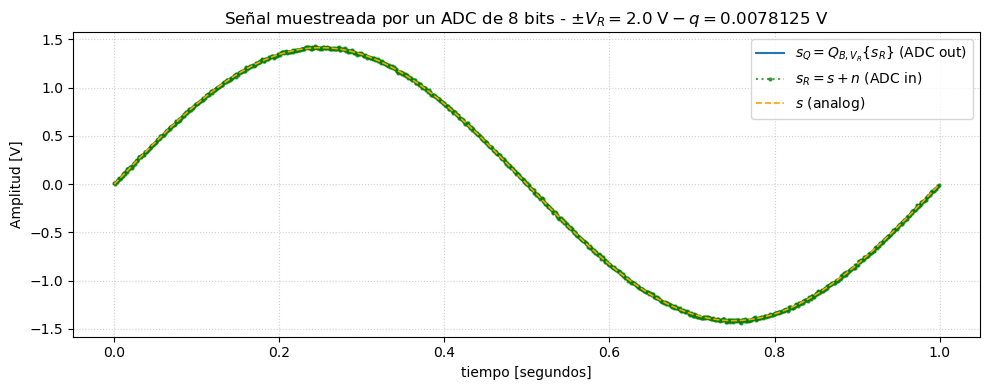

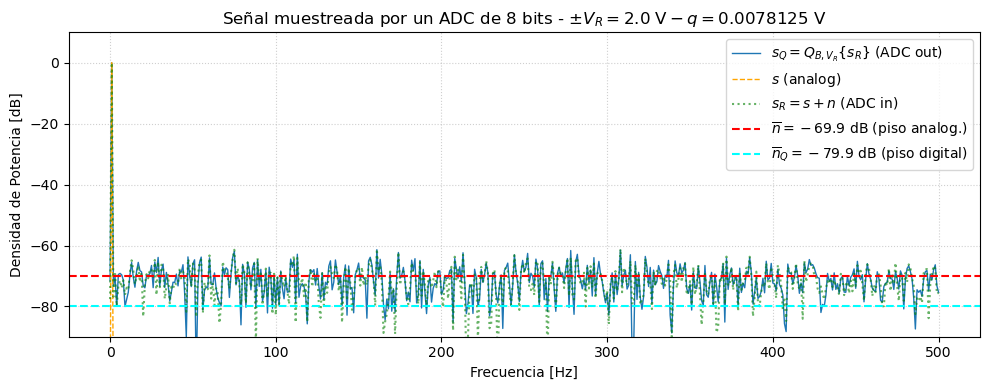

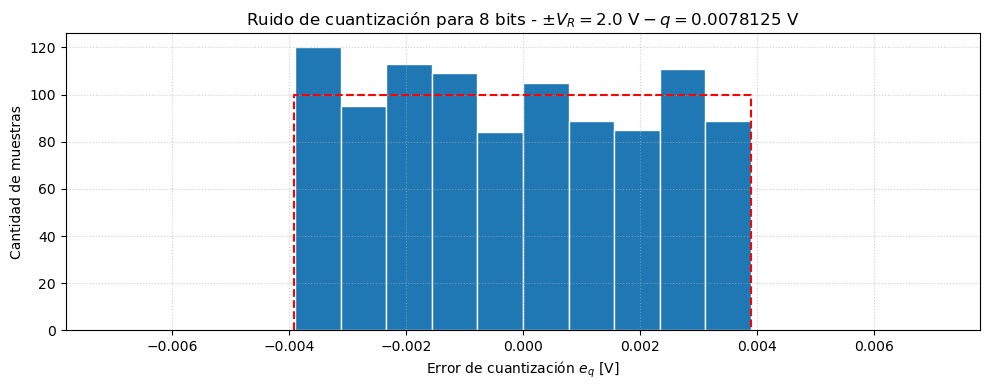

SNR Experimental: 42.41 dB
SNR Teórica: 42.52 dB


In [12]:
simular(bits_adc=8, escala_ruido=10)

<br>

$B = 16$ y $k_n = 0.1$

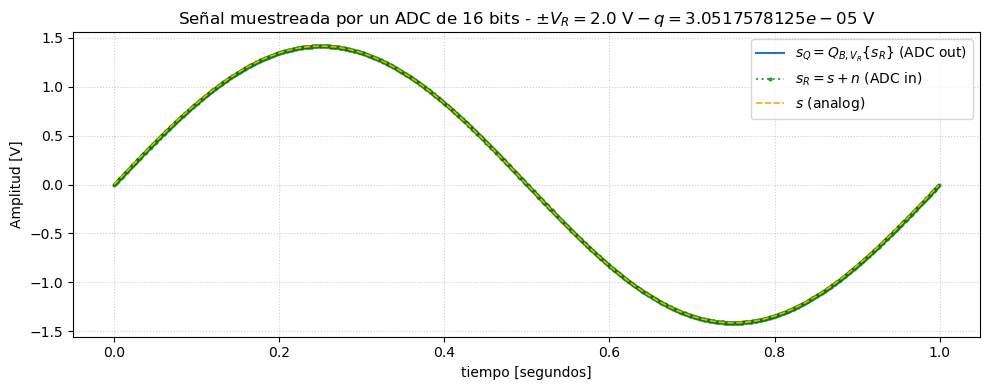

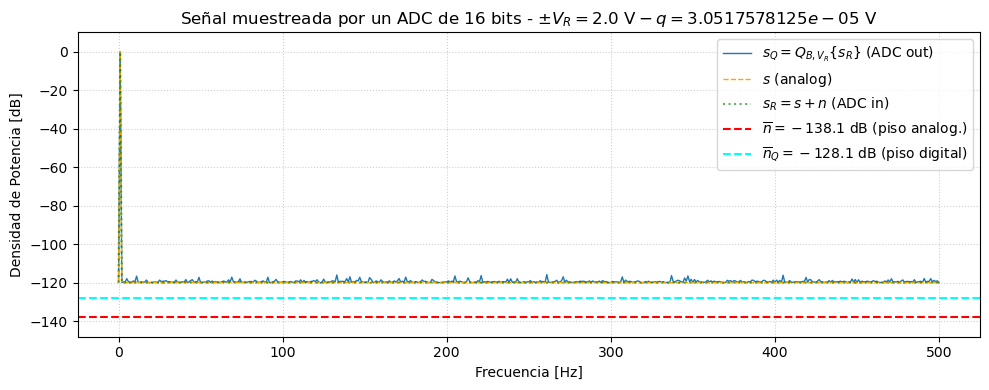

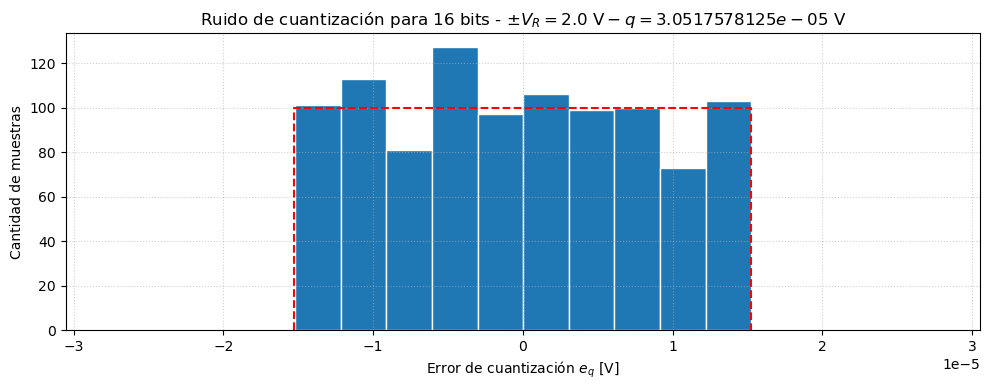

SNR Experimental: 100.76 dB
SNR Teórica: 100.69 dB


In [13]:
simular(bits_adc=16, escala_ruido=0.1)

<br>

$B = 16$ y $k_n = 1$

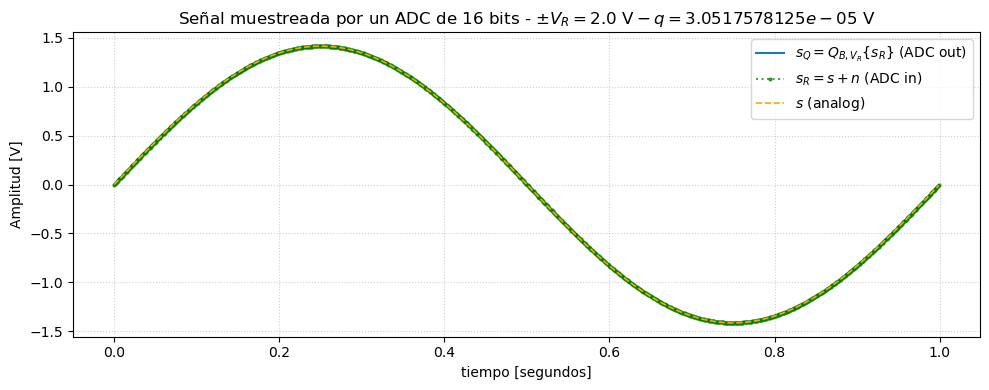

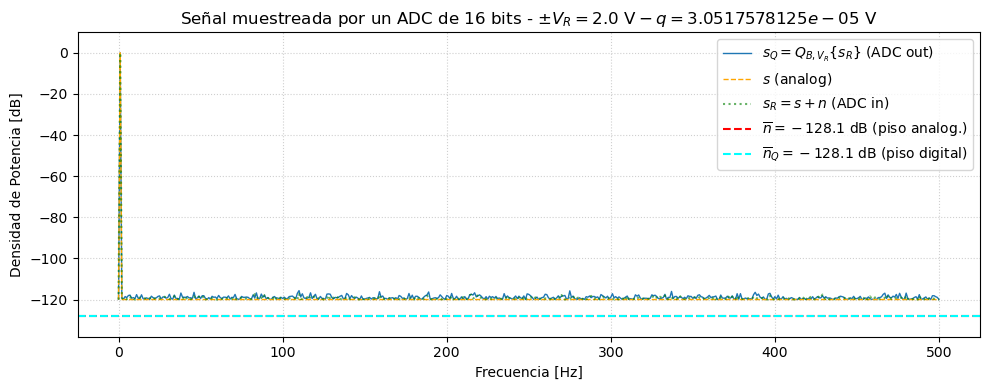

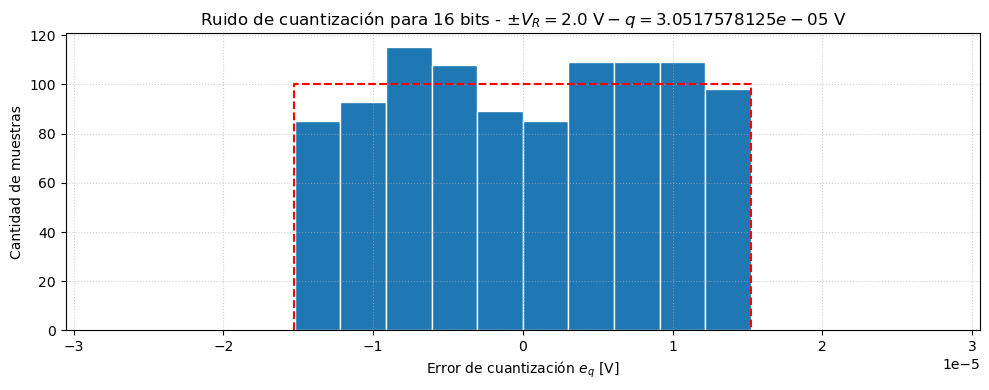

SNR Experimental: 98.25 dB
SNR Teórica: 98.09 dB


In [14]:
simular(bits_adc=16, escala_ruido=1)

<br>

$B = 16$ y $k_n = 10$

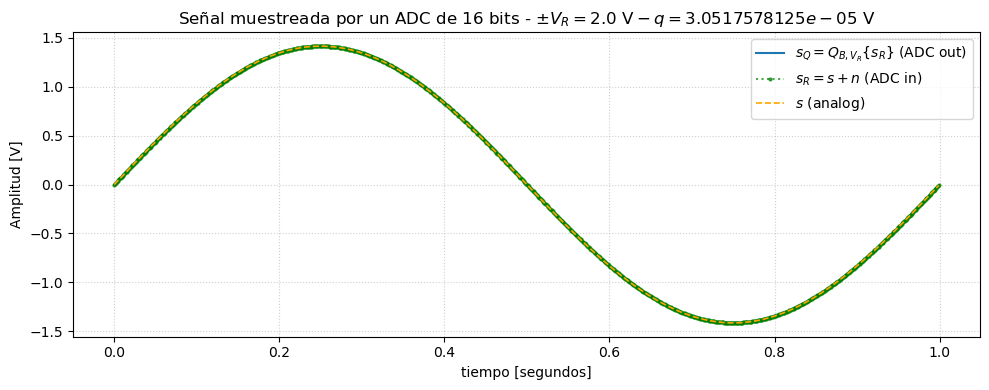

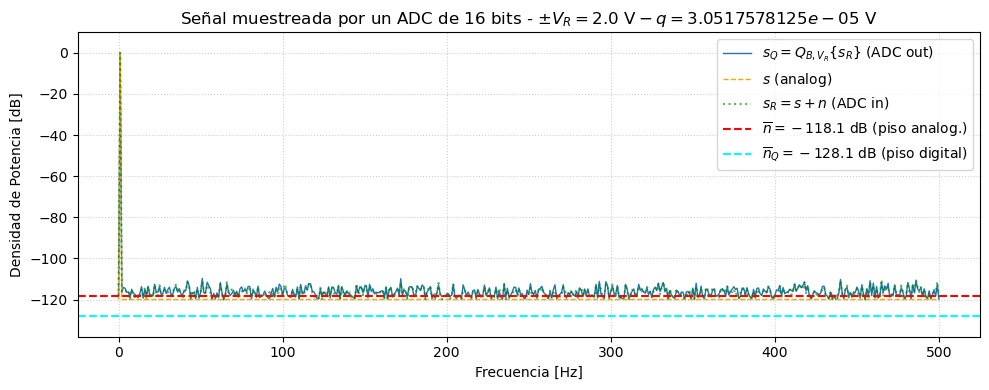

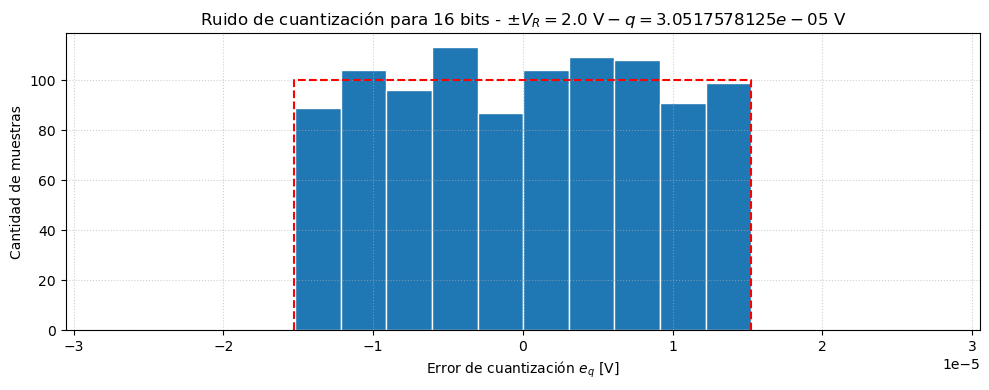

SNR Experimental: 90.81 dB
SNR Teórica: 90.69 dB


In [15]:
simular(bits_adc=16, escala_ruido=10)

### **Análisis de Resultados** 



| Resolución ($B$) | Ruido de Entrada ($k_n$) | Paso $q$ [V] | SNR Teórica [dB] | SNR Experimental [dB] | Diferencia | Límite del Sistema |
| :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **4 bits** | $k_n = 0.1$ | 0.125 V | 28.44 dB | **28.78 dB** | +0.34 dB | **Cuantización (ADC)** |
| **4 bits** | $k_n = 1.0$ | 0.125 V | 25.84 dB | **26.06 dB** | +0.22 dB | Mixto |
| **4 bits** | $k_n = 10.0$ | 0.125 V | 18.44 dB | **18.42 dB** | -0.02 dB | **Ruido Analógico** |
| **8 bits** | $k_n = 0.1$ | 0.0078 V | 52.52 dB | **53.01 dB** | +0.49 dB | **Cuantización (ADC)** |
| **8 bits** | $k_n = 1.0$ | 0.0078 V | 49.93 dB | **49.98 dB** | +0.05 dB | Mixto |
| **8 bits** | $k_n = 10.0$ | 0.0078 V | 42.52 dB | **42.41 dB** | -0.11 dB | **Ruido Analógico** |
| **16 bits** | $k_n = 0.1$ | $30.5\ \mu\text{V}$ | 100.69 dB | **100.76 dB** | +0.07 dB | **Cuantización (ADC)** |
| **16 bits** | $k_n = 1.0$ | $30.5\ \mu\text{V}$ | 98.09 dB | **98.25 dB** | +0.16 dB | Mixto |
| **16 bits** | $k_n = 10.0$ | $30.5\ \mu\text{V}$ | 90.69 dB | **90.81 dB** | +0.12 dB | **Ruido Analógico** |

<br>

### **A. ($k_n = 0.1$)**
Cuando configuramos un ruido analógico de entrada muy bajo ($k_n = 0.1$), el sistema está limitado por la cuantización del ADC. En 4 bits, la señal analógica es muy limpia, pero el ADC es tan "tosco" (escalones de $0.125\text{ V}$) que destruye la precisión, estancando el SNR experimental en $28.78\text{ dB}$. El error en el tiempo se ve como un "serrucho". Si subimos a 8 bits, el escalón cae a $7.8\text{ mV}$ y el SNR experimental aumenta a $53.01\text{ dB}$. En 16 bits, el ruido del ADC directamente desaparece abajo de todo (piso digital en $-128\text{ dB}$), logrando un SNR impecable de $100.76\text{ dB}$. Como se puede observar, en este escenario, mejorar el ADC (subir bits) tiene un impacto directo y enorme en la calidad de la señal.

<br>

### **B. ($k_n = 1$)**
En la simulación, en el caso de $k_n = 1$ la potencia del ruido analógico de entrada es exactamente igual a la potencia del ruido de cuantización del ADC ($P_n = P_q$). Para $B = 4$, ambos ruidos (analógico y digital) están empatados en potencia. En el espectro, las líneas punteadas roja y cian se superponen perfectamente en $-55.84\text{ dB}$. El SNR experimental dio $26.06\text{ dB}$. Esto significa que ambas etapas (la analógica previa y la digital del ADC) están degradando la señal por igual. Para los casos $B = 8$ y $B = 16$, se pudo notar que al subir los bits a 8 y 16, el SNR experimental salta a $49.98\text{ dB}$ y $98.25\text{ dB}$ respectivamente. Esta mejora en el SNR se debe a que el ruido analógico se calcula como un múltiplo del digital ($P_n = k_n \cdot P_q$). Al subir los bits, el paso $q$ se achica, haciendo que el ruido del ADC disminuya y provocando que el ruido analógico de entrada también se achique. 

<br>

### **C. ($k_n = 10$)**
Cuando el ruido analógico externo que ya viene con la señal es muy fuerte ($k_n = 10$), el sistema pasa a estar limitado por el ruido analógico. Si observamos las filas de $k_n = 10$, el SNR experimental se degrada notablemente en todas las resoluciones (cae a $18.42\text{ dB}$ en 4 bits, $42.41\text{ dB}$ en 8 bits y $90.81\text{ dB}$ en 16 bits). En frecuencia, el piso analógico (línea roja) sube $10\text{ dB}$ por encima del digital (línea cian), tapando por completo el error de cuantización del ADC. Por lo que el verdadero problema está afuera, y la única forma de mejorar la SNR real es agregar un filtro analógico antes del ADC para limpiar la señal de entrada. 

<br>

### **Histograma**
Aunque la teoría indica que el histograma del error de cuantización debe ser una distribución uniforme y plana entre $\pm q/2$, en las simulaciones observamos ondulaciones en la parte superior. Esto es completamente normal y se debe a que trabajamos con un número finito de muestras ($N=1000$), lo que genera dispersión estadística respecto al caso ideal infinito.

<br>

### **Conclusion**
A través de esta experiencia pudimos simular y cuantificar cómo interactúan el ruido analógico de entrada y el ruido digital de cuantización en un proceso de digitalización. Los resultados demuestran que la calidad final de la señal (SNR) no depende únicamente de tener un ADC con muchos bits, sino del balance entre el conversor y el ruido que ya trae la señal analógica. Cuando el ruido externo es bajo, el ADC es el cuello de botella y subir la resolución mejora notablemente el sistema. Sin embargo, cuando el ruido analógico es el que domina (caso $k_n = 10$), un ADC de alta resolución termina digitalizando "ruido con mucha precisión", por lo que si se quiere limpiar la señal de entrada, se debe agregar un filtro analogico antes del ADC. En el caso de $k_n = 1$, la potencia del ruido analógico que viene de afuera y la del ruido de cuantización propio del ADC se igualan ($P_n = P_q$). Esto nos asegura que ninguna de las dos etapas actúa como un cuello de botella, logrando el mejor compromiso posible. 